In [1]:
# Installation and set up
!pip install kagglehub[pandas-datasets]


In [2]:
# Imports
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
import math

In [3]:
# Set the path to the file you'd like to load
file_path = "cleaned_canada.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yuliiabulana/canada-housing",
  file_path,
)

df.head()

Using Colab cache for faster access to the 'canada-housing' dataset.


,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


In [4]:
df.describe()

,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Square Footage
count,44896.000000,44896.000000,4.489600e+04,44896.000000,44896.000000,44896.000000,44896.000000
mean,49.010267,-106.632760,1.070457e+06,3.214919,2.522652,2.485950,1787.726323
std,2.659066,22.270395,1.442961e+06,1.636517,1.423765,86.626599,1988.320406
min,42.045940,-135.856018,5.000000e+04,0.000000,0.000000,0.000000,140.000000
25%,48.477511,-122.887882,3.999900e+05,2.000000,2.000000,0.000000,975.000000
50%,49.217891,-119.395219,6.880000e+05,3.000000,2.000000,0.060000,1417.000000
75%,49.927914,-102.485638,1.200000e+06,4.000000,3.000000,0.180000,2198.000000
max,65.281488,-52.668600,5.880000e+07,37.000000,26.000000,8600.000000,290034.000000


# 1. Data Preparation

In this step, we're evaluating and using the best model to predict the missing column values and getting rid of of all NaN values.

## 1.1. Determining the best model to use for classification

In [5]:
# Drop rows with missing basement values to prepare training data
train_df = df.dropna(subset=['Basement'])

# Convert categorical values to valid data types (one-hot encoding)
train_df = pd.get_dummies(train_df, columns=['Garden', 'Property Type'], drop_first=True)

# Split data
midpoint = train_df.index.size // 2
train_data = train_df.iloc[:midpoint]
test_data = train_df.iloc[midpoint:]

# Get generated dummy column names for City and Property Type
garden_cols = [col for col in train_df.columns if col.startswith('Garden_')]
proptype_cols = [col for col in train_df.columns if col.startswith('Property Type_')]
feature_cols = ['Square Footage'] + garden_cols + proptype_cols

X_train = train_data[feature_cols]
X_test = test_data[feature_cols]
y_train = train_data['Basement']
y_test = test_data['Basement']

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_preds = lda.predict(X_test)

lda_report = classification_report(y_true=y_test, y_pred=lda_preds, labels=lda.classes_, zero_division=0)
print(lda_report)


              precision    recall  f1-score   support

    Finished       0.76      1.00      0.86      5665
 No basement       0.00      0.00      0.00      1412
     Partial       0.00      0.00      0.00       404

    accuracy                           0.76      7481
   macro avg       0.25      0.33      0.29      7481
weighted avg       0.57      0.76      0.65      7481



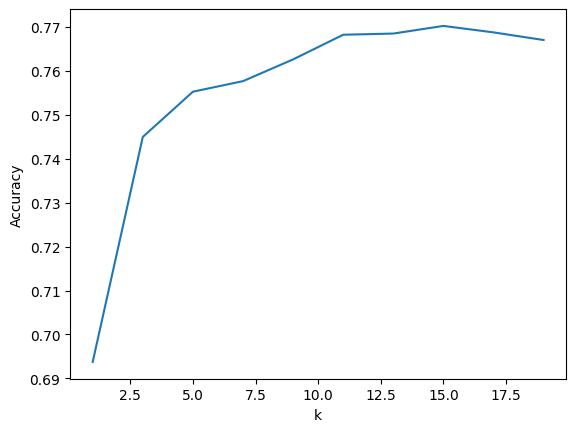


Best k value: 15


In [7]:
# Find the best k value
k_values = range(1, 20, 2)
accs = []

for k in k_values:
  knn = KNeighborsClassifier(k)
  knn.fit(X_train, y_train)
  accs.append(accuracy_score(y_test, knn.predict(X_test)))

plt.plot(k_values, accs)
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

print('\nBest k value:', k_values[accs.index(max(accs))])

In [8]:
# KNN with k = 15
knn = KNeighborsClassifier(15)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

knn_report = classification_report(y_true=y_test, y_pred=knn_preds, labels=knn.classes_, zero_division=0)
print(knn_report)

              precision    recall  f1-score   support

    Finished       0.77      0.99      0.87      5665
 No basement       0.71      0.10      0.17      1412
     Partial       0.20      0.00      0.00       404

    accuracy                           0.77      7481
   macro avg       0.56      0.36      0.35      7481
weighted avg       0.73      0.77      0.69      7481



In [9]:
# Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

logreg_report = classification_report(y_true=y_test, y_pred=logreg_preds, labels=logreg.classes_, zero_division=0)
print(logreg_report)

              precision    recall  f1-score   support

    Finished       0.76      1.00      0.86      5665
 No basement       0.00      0.00      0.00      1412
     Partial       0.00      0.00      0.00       404

    accuracy                           0.76      7481
   macro avg       0.25      0.33      0.29      7481
weighted avg       0.57      0.76      0.65      7481



## 1.2 Using KNN classification to predict and fill missing data points

## TODO: Need to justify this choice. Probably because the f1-score in KNN captures No basement, other algorithsm have 0 f1-score for no-basement case.

In [10]:
# Get all rows with missing basement values
missing_data = df[df['Basement'].isna()]
missing_data = pd.get_dummies(missing_data, columns=['Garden', 'Property Type'], drop_first=True)

# Predict missing data
X_missing = scaler.transform(missing_data[feature_cols])
preds = knn.predict(X_missing)

# Merge with original dataframe
filled_df = df.copy()
filled_df.loc[missing_data.index, 'Basement'] = preds

# Testing
print(filled_df['Basement'].isna().sum())  # All missing basement values filled
print (df.index.size == filled_df.index.size)  # No rows dropped

0
True


# 2. Pre-training

## 2.1. Using Clustering to divide data into related clusters

To avoid curse of dimensionality, especially during clustering, we're trying to limit the number of features we use for grouping different property types. The price per constructred square foot incorporates hidden features such as locality, number of rooms, house features, etc. So for clustering, we're grouping the houses based on price and the square footage correlation. For eg, older houses with bigger lots will have a lower price per square foot whereas newer townhomes will likely have higher price per square foot. So this metric will form these coherent groups.

In [11]:
# Extracing the clustering features

clustering_features = ['Square Footage', 'Price']
cluster_df = filled_df[clustering_features]

cluster_df.head()

,Square Footage,Price
0,891.0,839000.0
1,1881.0,1150000.0
2,912.0,149000.0
3,4374.0,1298000.0
4,1254.0,759900.0


In [12]:
cluster_df.describe()

,Square Footage,Price
count,44896.000000,4.489600e+04
mean,1787.726323,1.070457e+06
std,1988.320406,1.442961e+06
min,140.000000,5.000000e+04
25%,975.000000,3.999900e+05
50%,1417.000000,6.880000e+05
75%,2198.000000,1.200000e+06
max,290034.000000,5.880000e+07


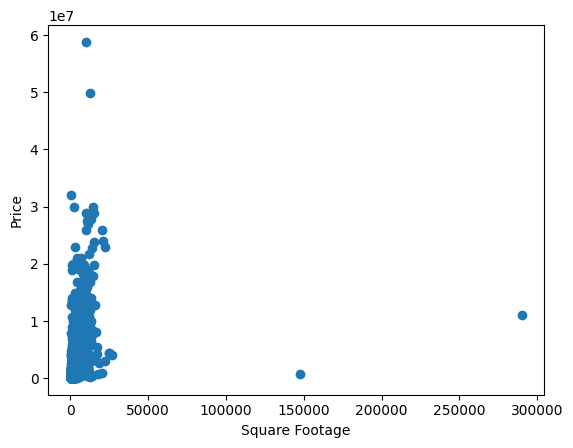

In [13]:
# Exploring the clustering features

plt.scatter(cluster_df[clustering_features[0]], cluster_df[clustering_features[1]])
plt.xlabel(clustering_features[0])
plt.ylabel(clustering_features[1])
plt.show()

The data has extreme outliers in terms of square footage and pricing that can affect clustering and training. Even scaling will not work because it will push most of the data within a small range.

To get rid of outliers, we'll be using the IQR (inter quartile range) and preserving data within 3 standard deviations only

In [14]:
# Removing the outliers in dataset using the IQR of 3

q1 = cluster_df[clustering_features].quantile(0.25)
q3 = cluster_df[clustering_features].quantile(0.75)
iqr = q3 - q1

lower_threshold = q1 - 3 * iqr
upper_threshold = q3 + 3 * iqr

mask = pd.Series(True, index=filled_df.index)  # start with all True

for col in clustering_features:
    mask &= (filled_df[col] >= lower_threshold[col]) & (filled_df[col] <= upper_threshold[col])

# Apply the mask safely
filled_df_clean = filled_df[mask].copy()
cluster_df_clean = cluster_df[mask].copy()

cluster_df_clean.describe()

,Square Footage,Price
count,42973.000000,4.297300e+04
mean,1636.263305,8.590907e+05
std,939.154101,6.770967e+05
min,140.000000,5.000000e+04
25%,960.000000,3.980000e+05
50%,1377.000000,6.590000e+05
75%,2080.000000,1.099900e+06
max,5866.000000,3.600000e+06


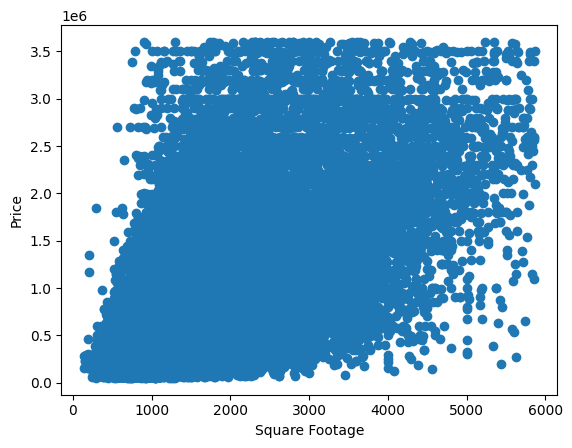

In [15]:
# Plotting the clean data after removing outliers

plt.scatter(cluster_df_clean[clustering_features[0]], cluster_df_clean[clustering_features[1]])
plt.xlabel(clustering_features[0])
plt.ylabel(clustering_features[1])
plt.show()

In [16]:
cluster_df.isna().any()

,0
Square Footage,False
Price,False


In [17]:
# Scaling the price and square footage

scaler = StandardScaler()
scaled_cluster_df = scaler.fit_transform(cluster_df_clean)

scaled_cluster_df[:5] ## Doing head() equivalent on numpy array

array([[-0.79355664, -0.02967215],
       [ 0.26059572,  0.42964719],
       [-0.77119584, -1.04874078],
       [ 2.91514305,  0.64823002],
       [-0.40703411, -0.14649581]])

In [18]:
# Training multiple clustering models to find best group

km = []

for i in range(2, 15, 2):
  km_i = KMeans(n_clusters=i, n_init='auto')
  km_i.fit(scaled_cluster_df)
  km.append(km_i)

len(km)

7

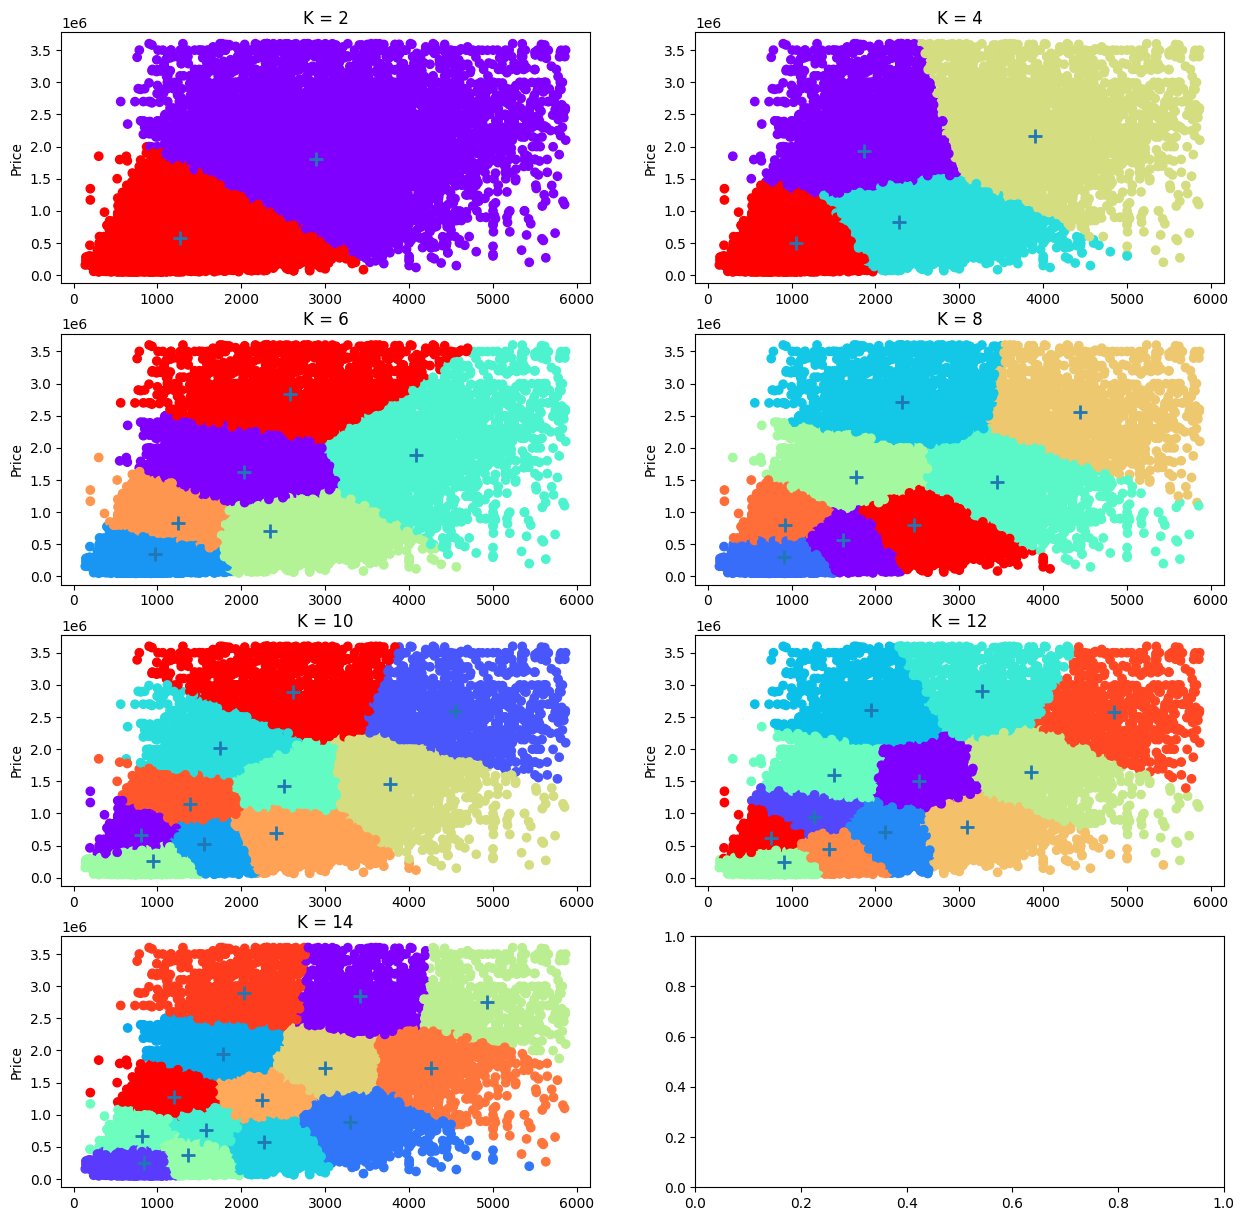

In [19]:
# Plotting models side by side

## We wanna show two subplots in each row
cols = 2
rows = math.ceil(len(km) / cols)

fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(15, 15))

for i in range(len(km)):
  row = i // cols
  col = i % cols
  ax_i = axs[row][col]
  ax_i.scatter(cluster_df_clean[clustering_features[0]], cluster_df_clean[clustering_features[1]], c=km[i].labels_, cmap='rainbow')
  ax_i.set_title(f'K = {km[i].n_clusters}')
  ax_i.set_ylabel(clustering_features[1])
  centers = scaler.inverse_transform(km[i].cluster_centers_)
  ax_i.scatter(centers[:,0], centers[:,1], marker='+', s=100, linewidth=2)

In [20]:
# Picking the model with cluster and appending to a new column

chosen_km = km[len(km) - 1] # Picking the last model with most clusters

housing_df = filled_df_clean.copy()
housing_df['cluster'] = chosen_km.labels_

housing_df.head()

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony,cluster
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,No,heat pump,carpet,NaN,No,municipal,No,No,No,6
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,No,heat pump,NaN,NaN,No,septic,No,No,No,10
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,No,NaN,laminate,tar,No,municipal,No,No,No,1
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,Yes,forced air,NaN,NaN,No,municipal,No,No,No,11
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,No,radiant,NaN,NaN,No,none,No,No,No,5


In [21]:
clustered_houses = {
    cluster: df
    for cluster, df in housing_df.groupby('cluster')
}

# 3. Training

## 3.1 Feature Engineering to find the best features for house price prediction

In [97]:
# Picking one of the clustered dataframe to test with different feature-sets

# selected_cluster = list(clustered_houses.keys())[0]
sample_df = df.copy()

sample_df.head()

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,...,Exterior,Fireplace,Heating,Flooring,Roof,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,...,NaN,No,heat pump,carpet,NaN,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,...,NaN,No,heat pump,NaN,NaN,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,...,Metal,No,NaN,laminate,tar,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,...,NaN,Yes,forced air,NaN,NaN,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,...,NaN,No,radiant,NaN,NaN,No,none,No,No,No


In [67]:
# Features Definitions
target = 'Price'

categorical_cols = [
    'City',
    'Province',
    'Property Type',
    'Basement',
    'Exterior',
    'Heating',
    'Flooring',
    'Roof',
    'Sewer'
]

numeric_cols = [
    'Bedrooms',
    'Bathrooms',
    'Square Footage',
    'Acreage',
    'Latitude',
    'Longitude'
]

binary_cols = [
    'Garage',
    'Parking',
    'Fireplace',
    'Waterfront',
    'Pool',
    'Garden',
    'Balcony'
]

binary_map = {'Yes': 1, 'No': 0}

In [108]:
# Hydrating with Enhanced Columns

def get_hydrated_df(sample_df):
  # Replacing 'Yes'/'No' with 1/0
  for col in binary_cols:
      if col in sample_df.columns:
          sample_df[col] = sample_df[col].map(binary_map)

  ## One-hot encoding
  df_encoded = pd.get_dummies(sample_df, columns=categorical_cols, drop_first=True)

  ## Interaction Terms
  df_encoded['sqft_per_bedroom'] = df_encoded['Square Footage'] / (df_encoded['Bedrooms'] + 1)
  df_encoded['bath_bed_ratio'] = df_encoded['Bathrooms'] / (df_encoded['Bedrooms'] + 1)

  df_encoded['sqft_x_bedrooms'] = df_encoded['Square Footage'] * df_encoded['Bedrooms']
  df_encoded['sqft_x_bathrooms'] = df_encoded['Square Footage'] * df_encoded['Bathrooms']

  df_encoded['luxury_score'] = (
      df_encoded['Fireplace'] + df_encoded['Waterfront'] +
      df_encoded['Pool'] + df_encoded['Garden'] + df_encoded['Balcony']
  )

  ## Log transforms
  df_encoded['log_sqft'] = np.log1p(df_encoded['Square Footage'])
  df_encoded['log_acreage'] = np.log1p(df_encoded['Acreage'])

  ## Polynomial Features

  poly = PolynomialFeatures(degree=2, include_bias=False)

  poly_features = df_encoded[['Square Footage', 'Bedrooms', 'Bathrooms']]
  poly_data = poly.fit_transform(poly_features)

  poly_cols = poly.get_feature_names_out()
  # Cleaning auto-generated column names for clarity
  poly_cols = [col.replace(' ', '_').replace('^', '_pow_') for col in poly_cols]

  poly_df = pd.DataFrame(poly_data, columns=poly_cols, index=df_encoded.index)

  ## polynomial features made training super slow so they're being excluded altogether

  # df_encoded = pd.concat([df_encoded, poly_df], axis=1)

  return df_encoded


df_encoded = get_hydrated_df(sample_df)
df_encoded.head()

,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Square Footage,Garage,Parking,Fireplace,...,Sewer_none,Sewer_private,Sewer_septic,sqft_per_bedroom,bath_bed_ratio,sqft_x_bedrooms,sqft_x_bathrooms,luxury_score,log_sqft,log_acreage
0,50.976585,-118.173149,839000.0,3.0,2.0,0.00,891.0,NaN,NaN,NaN,...,False,False,False,222.75,0.500000,2673.0,1782.0,NaN,6.793466,0.000000
1,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,1881.0,NaN,NaN,NaN,...,False,False,True,470.25,0.500000,5643.0,3762.0,NaN,7.540090,0.277632
2,49.825230,-119.603253,149000.0,2.0,1.0,0.00,912.0,NaN,NaN,NaN,...,False,False,False,304.00,0.333333,1824.0,912.0,NaN,6.816736,0.000000
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,4374.0,NaN,NaN,NaN,...,False,False,False,729.00,0.666667,21870.0,17496.0,NaN,8.383662,0.524729
4,49.221673,-122.596637,759900.0,3.0,2.0,0.00,1254.0,NaN,NaN,NaN,...,True,False,False,313.50,0.500000,3762.0,2508.0,NaN,7.134891,0.000000


In [75]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Scale
scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [93]:
feature_sets = {
    "baseline": [
        'Bedrooms', 'Bathrooms', 'Square Footage', 'Acreage'
    ],

    "ratios": [
        'sqft_per_bedroom', 'bath_bed_ratio', 'log_sqft'
    ],

    "interactions": [
        'sqft_x_bedrooms', 'sqft_x_bathrooms', 'luxury_score'
    ],

    "amenities": [
        'Garden', 'Fireplace', 'Pool', 'Waterfront', 'Balcony'
    ],

    "location": [
        'Latitude', 'Longitude'
    ],

    ## Made the model very slow so excluding them
    # "polynomial": list(poly_cols),
}

# Adding categorical columns
encoded_cat_cols = [col for col in X.columns if any(c in col for c in categorical_cols)]
feature_sets["categorical_full"] = encoded_cat_cols

feature_sets["full_model"] = list(X.columns)

In [71]:
# Train and validate
results = []

for name, features in feature_sets.items():
    model = LinearRegression()
    model.fit(X_train[features], y_train)

    preds = model.predict(X_test[features])
    r2 = r2_score(y_test, preds)

    print(f"'{name}' R2 = {r2}")
    results.append((name, r2))

results_df = pd.DataFrame(results, columns=['Feature Set', 'R2'])
results_df = results_df.sort_values(by='R2', ascending=False)

results_df

'baseline' R2 = -0.013226666198831838
'ratios' R2 = 0.159427413710576
'interactions' R2 = 0.3276126603511388
'amenities' R2 = 0.06196604638395231
'location' R2 = 0.09389936679662636
'hybrid' R2 = 0.22692410512068018
'categorical_full' R2 = 0.30563528035549603
'full_model' R2 = 0.2645145858417508


,Feature Set,R2
2,interactions,0.327613
6,categorical_full,0.305635
7,full_model,0.264515
5,hybrid,0.226924
1,ratios,0.159427
4,location,0.093899
3,amenities,0.061966
0,baseline,-0.013227


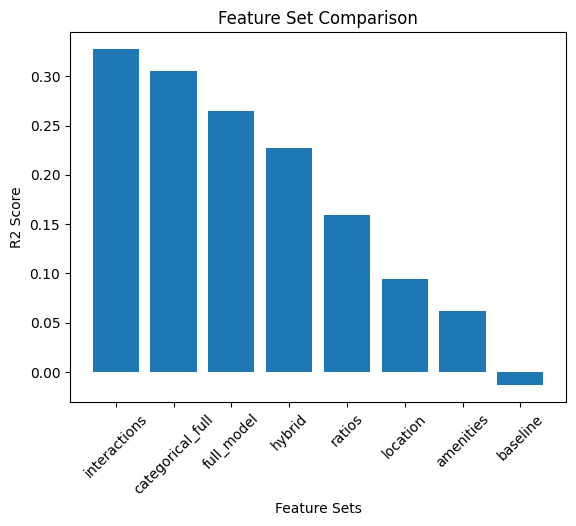

In [72]:
plt.figure()
plt.bar(results_df['Feature Set'], results_df['R2'])
plt.xticks(rotation=45)
plt.xlabel("Feature Sets")
plt.ylabel("R2 Score")
plt.title("Feature Set Comparison")
plt.show()

In [94]:
chosen_features = list(set([]
                           + feature_sets["interactions"]
                           + feature_sets["categorical_full"]
                           + feature_sets["ratios"]
                           + feature_sets["amenities"]
                           + feature_sets["location"]
                           ))

model = LinearRegression()
model.fit(X_train[chosen_features], y_train)

preds = model.predict(X_test[chosen_features])
r2 = r2_score(y_test, preds)

print(f"R2 = {r2}")

R2 = 0.4702775746101946


## 3.2 Regression on Clusters to build Price Predictor

In [115]:
# Linear Regression is applied to each cluster to predict house prices
lr_models = {}
lr_results = {}

for cluster_id, cluster_df in clustered_houses.items():
  print(f"\nCluster {cluster_id}")
  df_cluster_encoded = get_hydrated_df(cluster_df.copy())

  # Features and target
  X = df_cluster_encoded.drop(columns=['Price'])
  y = df_cluster_encoded['Price']

  scaler = StandardScaler()
  X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
  X_train, X_test, y_train, y_test = train_test_split(
      X_scaled, y, test_size=0.2, random_state=42
  )

  # Not all clusters may have all cities or features. Align X_train and X_test with chosen_features.
  chosen_features_sub = [col for col in chosen_features if col in X_train.columns]

  # Linear Regression model
  lr = LinearRegression()
  lr.fit(X_train[chosen_features_sub], y_train)

  # Predict Price
  y_pred = lr.predict(X_test[chosen_features_sub])

  # Evaluate model
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print("MSE:", mse)
  print("R2:", r2)

  lr_models[cluster_id] = lr
  lr_results[cluster_id] = { "mse":mse , "r2" : r2 }


Cluster 0
MSE: 2016461354250.267
R2: -13.619916143625456

Cluster 1
MSE: 5455242197.797834
R2: 0.5477903297804217

Cluster 2
MSE: 47026349384.60059
R2: 0.33766304447233786

Cluster 3
MSE: 282127564445.6642
R2: -4.216887949928331

Cluster 4
MSE: 22103359884.648968
R2: 0.4271296686052032

Cluster 5
MSE: 10565484169.799421
R2: 0.40625509993119857

Cluster 6
MSE: 117149194440.47968
R2: -4.787307557407255

Cluster 7
MSE: 15302986631.685665
R2: 0.08394383958928275

Cluster 8
MSE: 218864161005.88507
R2: -0.627608595729662

Cluster 9
MSE: 86623674098.10974
R2: -0.2109154471376311

Cluster 10
MSE: 24402540954.263996
R2: 0.2872137254855083

Cluster 11
MSE: 4096361597504.5513
R2: -33.30971612856187

Cluster 12
MSE: 1420479391639.1555
R2: -9.661138752248435

Cluster 13
MSE: 82024686104.4353
R2: -1.1726898580951333


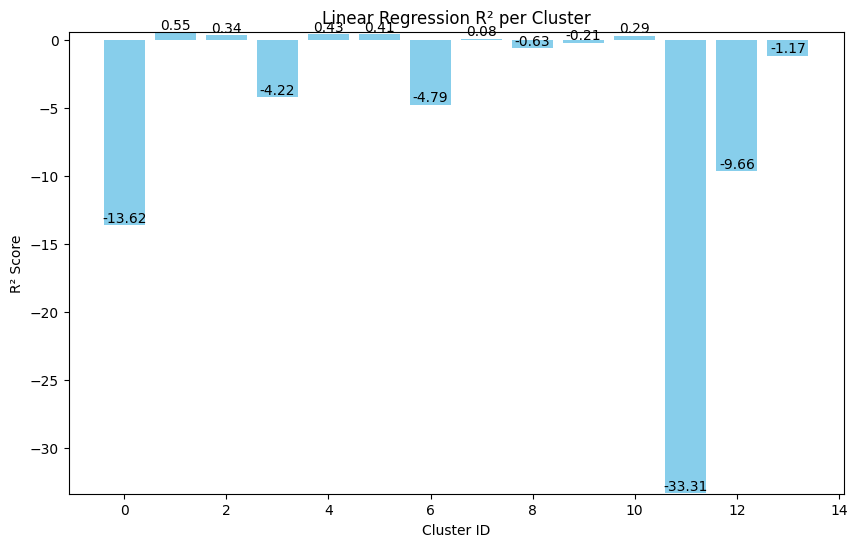

In [116]:
results_df = pd.DataFrame.from_dict(lr_results, orient='index')
results_df.index.name = 'Cluster_ID'
results_df.reset_index(inplace=True)

plt.figure(figsize=(10,6))
bars = plt.bar(results_df['Cluster_ID'], results_df['r2'], color='skyblue')
plt.xlabel("Cluster ID")
plt.ylabel("R² Score")
plt.title("Linear Regression R² per Cluster")
plt.ylim(min(results_df['r2'])-0.05, max(results_df['r2'])+0.05)

# Annotate bars
for bar, score in zip(bars, results_df['r2']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
             f"{score:.2f}", ha='center', va='bottom')

plt.show()

# 4. Calculate Readl Estate Deals

## 4.1 Finding the top 5 deals in each cluster

In [119]:
top_deals = []

for cluster_id, cluster_df in clustered_houses.items():
    lr = lr_models[cluster_id]

    # Prepare features same way as during training
    df_encoded = get_hydrated_df(cluster_df.copy())

    chosen_features_sub = [col for col in chosen_features if col in df_encoded.columns]
    # Some clusters may not have all features
    X = df_encoded[chosen_features_sub]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

    y_pred = lr.predict(X_scaled)

    # Compute discount delta
    df_encoded['Predicted_Price'] = y_pred
    df_encoded['Discount_Value'] = df_encoded['Predicted_Price'] - df_encoded['Price']

    # Top 5 discounted properties (largest positive delta)
    top_5 = df_encoded.nlargest(5, 'Discount_Value').copy()
    top_5['Cluster_ID'] = cluster_id

    top_deals.append(top_5)

# Combine all clusters
top_deals_df = pd.concat(top_deals, axis=0)
top_deals_df.sort_values('Discount_Value', ascending=False, inplace=True)
top_deals_df.reset_index(drop=True, inplace=True)

top_deals_df[['Cluster_ID', 'Price', 'Predicted_Price', 'Discount_Value']]

,Cluster_ID,Price,Predicted_Price,Discount_Value
0,12,2650000.0,1.271920e+07,1.006920e+07
1,11,1799000.0,1.150391e+07,9.704909e+06
2,12,2998000.0,1.261768e+07,9.619680e+06
3,3,2150000.0,9.432048e+06,7.282048e+06
4,12,2499900.0,7.293247e+06,4.793347e+06
...,...,...,...,...
65,1,92499.0,4.082238e+05,3.157248e+05
66,1,149900.0,4.606648e+05,3.107648e+05
67,5,534900.0,8.219304e+05,2.870304e+05
68,5,499000.0,7.655161e+05,2.665161e+05
